# Unveiling the Android App Market: Analyzing Google Play Store Data

## Objective

The objective of this project is to analyze and understand the dynamics of the Android app market using Google Play Store data. This includes cleaning and preparing the dataset, exploring app categories, analyzing key metrics such as ratings, size, installs, and pricing, and visualizing trends to gain meaningful insights. Additionally, user review data is analyzed to assess overall sentiment, helping to better understand user perceptions of mobile applications.

## Dataset Description

The dataset used in this project is sourced from the Google Play Store and provides detailed information about Android applications and user reviews. It consists of two CSV files, each serving a distinct purpose in the analysis:

apps.csv:
This file contains metadata about Android applications, including app name, category, rating, number of reviews, size, number of installs, type (free or paid), price, content rating, genres, last update, and Android version requirements. This dataset is primarily used for data cleaning, category exploration, and metrics analysis.

user_reviews.csv:
This file includes user-generated reviews for various applications along with sentiment labels (positive, negative, neutral) and sentiment polarity scores. This dataset is used specifically for performing sentiment analysis to understand user opinions and feedback.

Together, these datasets enable a comprehensive analysis of the Android app market by combining application-level statistics with user sentiment insights.

## Data Loading and Initial Inspection

In this step, both datasets are loaded into the notebook using Pandas.  
Initial inspection is performed to understand the structure, columns, and sample records of the data.  
This helps identify data types, missing values, and overall dataset size before cleaning and analysis.

In [1]:
import pandas as pd
import numpy as np

apps_df = pd.read_csv("apps.csv")
reviews_df = pd.read_csv("user_reviews.csv")

apps_df.head(), reviews_df.head()

(   Unnamed: 0                                                App  \
 0           0     Photo Editor & Candy Camera & Grid & ScrapBook   
 1           1                                Coloring book moana   
 2           2  U Launcher Lite – FREE Live Cool Themes, Hide ...   
 3           3                              Sketch - Draw & Paint   
 4           4              Pixel Draw - Number Art Coloring Book   
 
          Category  Rating  Reviews  Size     Installs  Type Price  \
 0  ART_AND_DESIGN     4.1      159  19.0      10,000+  Free     0   
 1  ART_AND_DESIGN     3.9      967  14.0     500,000+  Free     0   
 2  ART_AND_DESIGN     4.7    87510   8.7   5,000,000+  Free     0   
 3  ART_AND_DESIGN     4.5   215644  25.0  50,000,000+  Free     0   
 4  ART_AND_DESIGN     4.3      967   2.8     100,000+  Free     0   
 
   Content Rating                     Genres      Last Updated  \
 0       Everyone               Art & Design   January 7, 2018   
 1       Everyone  Art & Desig

In [2]:
print("Apps dataset shape:", apps_df.shape)
print("Reviews dataset shape:", reviews_df.shape)

Apps dataset shape: (9659, 14)
Reviews dataset shape: (64295, 5)


In [3]:
apps_df.info()
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   object 
 7   Type            9659 non-null   object 
 8   Price           9659 non-null   object 
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.0+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #

## Data Cleaning and Type Conversion

This step focuses on cleaning the datasets and correcting data types to ensure accurate analysis.  
Missing values are handled, irrelevant symbols are removed, and columns are converted into appropriate numerical formats.  
This preparation is essential for reliable visualization and meaningful insights.

In [4]:
# Remove duplicate apps
apps_df = apps_df.drop_duplicates()

apps_df = apps_df.dropna(subset=['Rating', 'Type', 'Price', 'Installs'])

apps_df['Installs'] = apps_df['Installs'].str.replace(',', '').str.replace('+', '')
apps_df['Installs'] = apps_df['Installs'].astype(int)

apps_df['Price'] = apps_df['Price'].str.replace('$', '')
apps_df['Price'] = apps_df['Price'].astype(float)

apps_df['Rating'] = apps_df['Rating'].astype(float)

apps_df.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [5]:
# Drop rows with missing sentiment values
reviews_df = reviews_df.dropna(subset=['Sentiment', 'Sentiment_Polarity'])

reviews_df['Sentiment_Polarity'] = reviews_df['Sentiment_Polarity'].astype(float)

reviews_df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
5,10 Best Foods for You,Best way,Positive,1.00,0.300000


## Category Exploration

This section explores the distribution of Android applications across different categories available on the Google Play Store.  
By analyzing the number of apps in each category, we can identify which categories are most saturated and which have fewer applications.

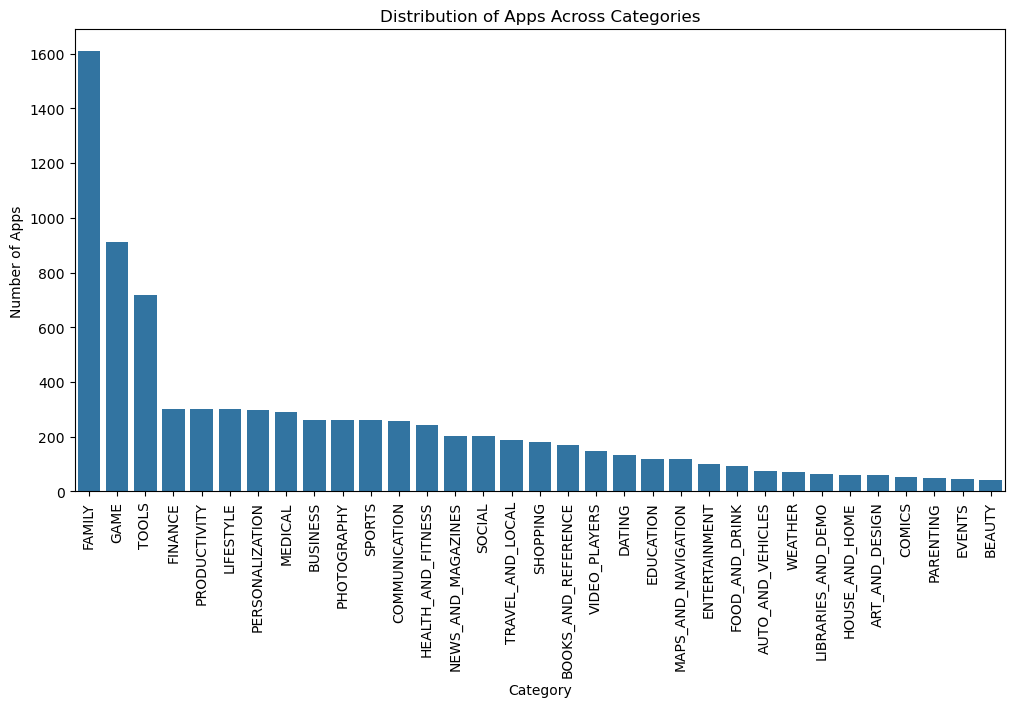

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

category_counts = apps_df['Category'].value_counts()

# Plot category distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=category_counts.index, y=category_counts.values)
plt.xticks(rotation=90)
plt.title("Distribution of Apps Across Categories")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.show()

## Metrics Analysis

This section analyzes key metrics of Android applications, including ratings, number of installs, app size, and pricing.  
These metrics help in understanding user preferences, app popularity, and pricing trends within the Google Play Store.

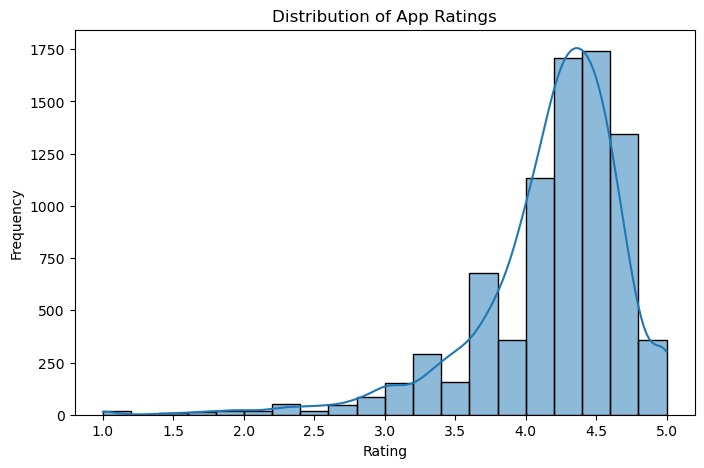

In [7]:
# Distribution of app ratings
plt.figure(figsize=(8, 5))
sns.histplot(apps_df['Rating'], bins=20, kde=True)
plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

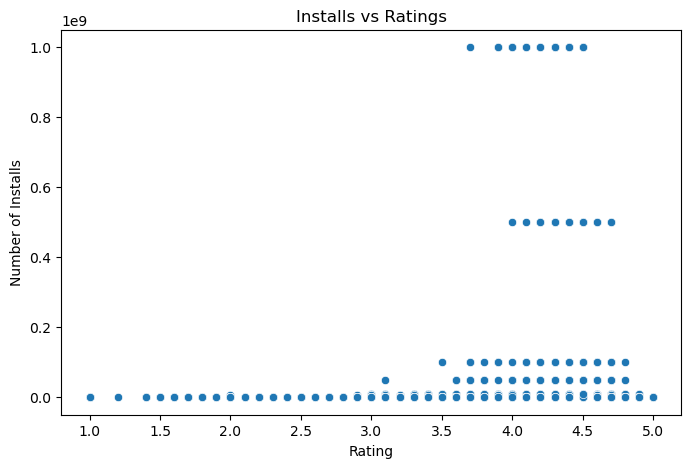

In [8]:
# Relationship between installs and ratings
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Rating', y='Installs', data=apps_df)
plt.title("Installs vs Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Installs")
plt.show()

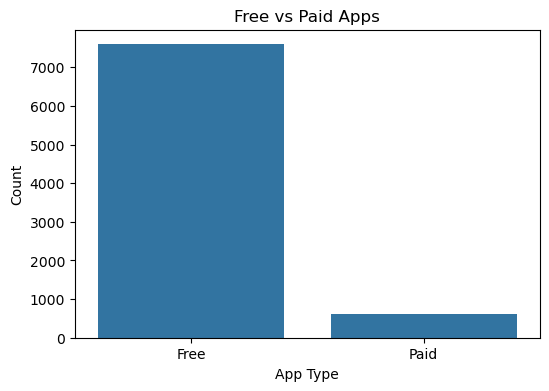

In [9]:
# Free vs Paid apps distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Type', data=apps_df)
plt.title("Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Count")
plt.show()

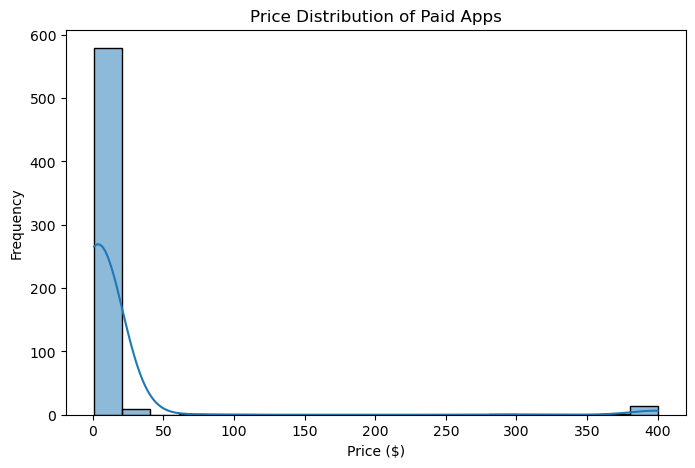

In [10]:
# Price distribution for paid apps
paid_apps = apps_df[apps_df['Price'] > 0]

plt.figure(figsize=(8, 5))
sns.histplot(paid_apps['Price'], bins=20, kde=True)
plt.title("Price Distribution of Paid Apps")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.show()

## Sentiment Analysis

This section focuses on analyzing user sentiments based on app reviews available in the dataset.  
By examining sentiment labels and polarity scores, we can understand how users perceive Android applications and identify overall trends in user satisfaction.

In [11]:
# Count of each sentiment type
sentiment_counts = reviews_df['Sentiment'].value_counts()
sentiment_counts

Sentiment
Positive    23998
Negative     8271
Neutral      5163
Name: count, dtype: int64

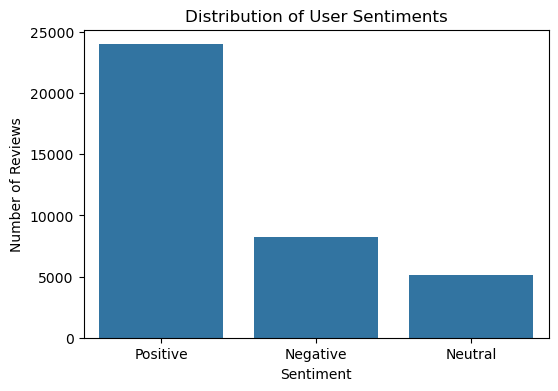

In [12]:
# Plot sentiment distribution
plt.figure(figsize=(6, 4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)
plt.title("Distribution of User Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

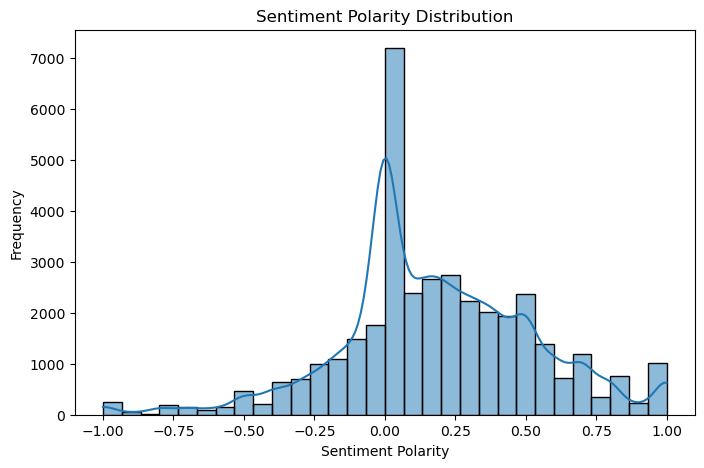

In [13]:
# Distribution of sentiment polarity
plt.figure(figsize=(8, 5))
sns.histplot(reviews_df['Sentiment_Polarity'], bins=30, kde=True)
plt.title("Sentiment Polarity Distribution")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Frequency")
plt.show()

## Insights and Interpretation

The analysis of Google Play Store data reveals several important trends within the Android app market. Certain categories dominate the marketplace, indicating high developer interest and user demand. App ratings generally remain high, suggesting overall positive user experiences, while the number of installs varies significantly across apps.

Free applications account for the majority of the market, highlighting user preference for free-to-use apps. Paid applications tend to have lower install counts but follow distinct pricing patterns. Sentiment analysis of user reviews shows that positive feedback outweighs negative sentiment, reflecting general user satisfaction with Android applications.

These insights help in understanding market dynamics, user behavior, and factors influencing app success on the Google Play Store.

## Conclusion

This project successfully analyzed the Google Play Store dataset to uncover key insights about the Android app market. Through data cleaning, category exploration, metrics analysis, and sentiment analysis, meaningful patterns related to app popularity, pricing, ratings, and user feedback were identified.

The results show that certain app categories dominate the market, most applications are free, and higher ratings generally correlate with increased user engagement. Sentiment analysis further revealed that positive user feedback is more prevalent, indicating overall satisfaction with Android applications.

Overall, this project enhanced skills in data preparation, visualization, and interpretation, providing a comprehensive understanding of market dynamics within the Google Play Store ecosystem.